# MAF On Oxford Flowers From Hugging Face

This notebook implements a masked autoregressive flow (MAF), trained on a tiny image-generation setup built from the Hugging Face Oxford Flowers dataset.

Default choices in this notebook:
- Dataset: `nkirschi/oxford-flowers`
- Resolution: `16 x 16` [NOTE: you may want to lower this during experimenting, or increase it, to sample larger images]
- Channels: RGB
- Training subset: a small subset of the train split for notebook-friendly runtime

The model is still a fully-connected MAF over flattened pixels, so the goal here is a compact generative modeling demo rather than state-of-the-art image quality.

### Possible extension

A possible extension to this code is to implement a conditional normalising flow. This means to fit the PDF $p(x|y)$ instead of simply $p(x)$. 

You would need to use the labels provided with the dataset. These are 102 different integers that classify the species of flower. By modelling $p(x|y)$ - where $y$ is this label - you can sample a certain species of flower.

You would need to input the label into the model during training, adding or embedding it into the `MADE` model. Afterwards, you can test the sampling by choosing a random integer $y\in [0, 102]$ and sampling a set of images.

An initial first go could simply add the labels, input into the MADE, onto `x` going into the MADE model.

/Users/Jed.Homer/phd/generative_models/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


Train vectors: (5000, 192)
Test vectors: (256, 192)
Train labels: (5000,)
Test labels: (256,)
Image resolution: 8x8
Channels: 3
Epoch    1 | NLL 221.7632
Epoch    5 | NLL 89.1841
Epoch   10 | NLL 50.1541
Epoch   15 | NLL 31.2096
Epoch   20 | NLL 19.8096
Epoch   25 | NLL 11.1455
Epoch   30 | NLL 3.9688
Epoch   35 | NLL -1.4943
Epoch   40 | NLL -4.9565
Epoch   45 | NLL -10.4724
Epoch   50 | NLL -14.1706
Epoch   55 | NLL -17.3971
Epoch   60 | NLL -19.5240
Epoch   65 | NLL -22.9566
Epoch   70 | NLL -25.9085
Epoch   75 | NLL -28.1100
Epoch   80 | NLL -29.6134
Epoch   85 | NLL -31.3382
Epoch   90 | NLL -33.6388
Epoch   95 | NLL -36.2021
Epoch  100 | NLL -36.6515
Epoch  105 | NLL -38.3659
Epoch  110 | NLL -38.6762
Epoch  115 | NLL -42.7964
Epoch  120 | NLL -42.4455
Epoch  125 | NLL -44.0679
Epoch  130 | NLL -44.0898
Epoch  135 | NLL -46.0173
Epoch  140 | NLL -46.0469
Epoch  145 | NLL -48.6681
Epoch  150 | NLL -49.0119
Epoch  155 | NLL -49.2743
Epoch  160 | NLL -50.2706
Epoch  165 | NLL -53.59

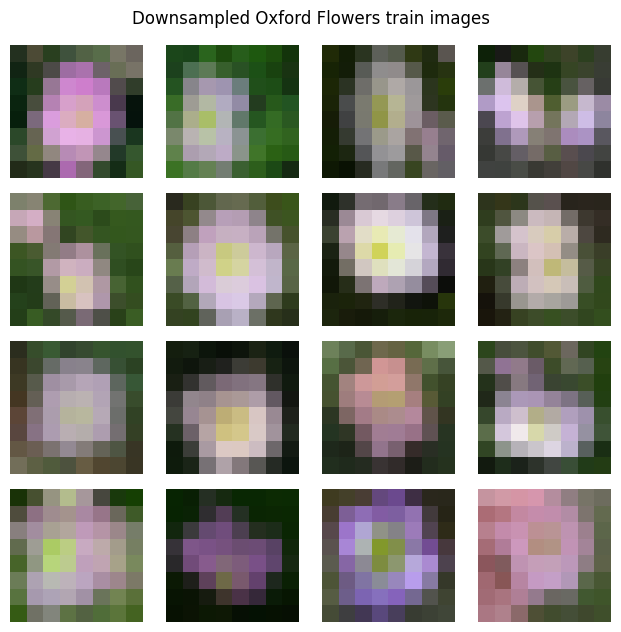

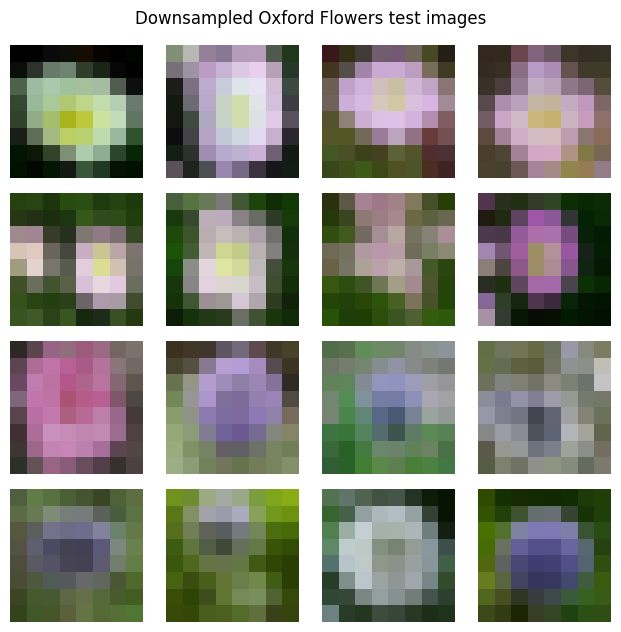

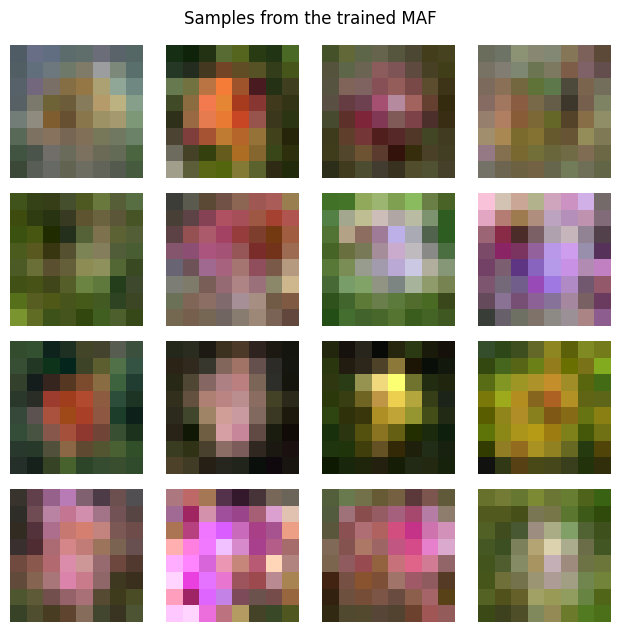

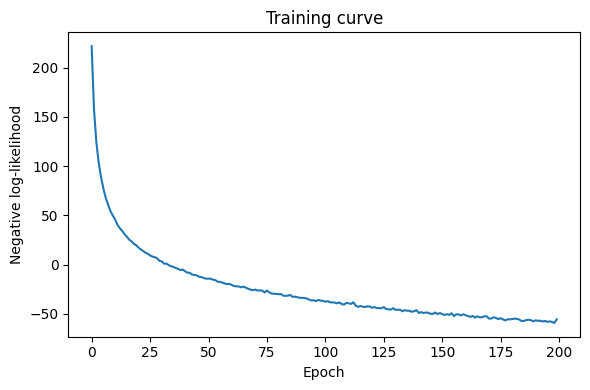

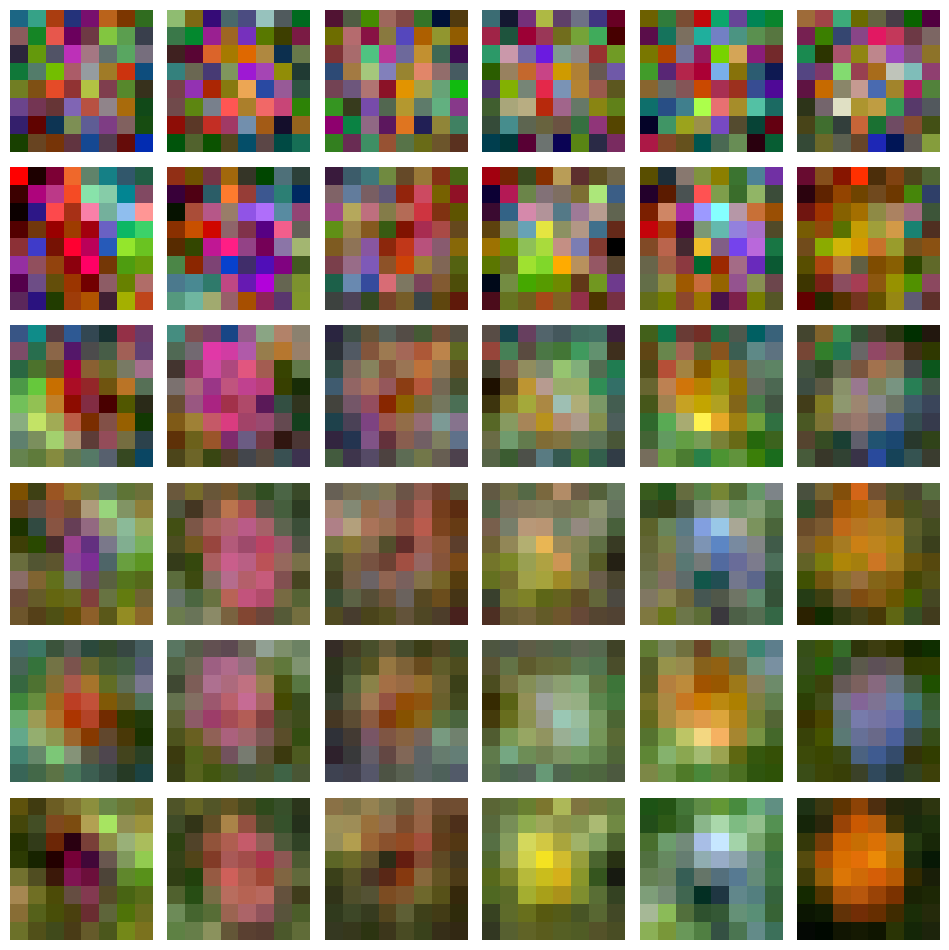

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset # Hugging face datasets package

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Configuration
# ============================================================

DATASET_NAME = "nkirschi/oxford-flowers"
N_PIX = 8
USE_RGB = True
MAX_TRAIN_SAMPLES = 5000
MAX_TEST_SAMPLES = 256
BATCH_SIZE = 64
HIDDEN_DIM = 256
N_FLOWS = 5
EPOCHS = 200 # This may take ~10 minutes or longer, try smaller n_pix / model for prototyping
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-6

RESAMPLE_BILINEAR = Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR


# ============================================================
# Utilities
# ============================================================


def chw_to_hwc(images: np.ndarray) -> np.ndarray:
    return np.transpose(images, (0, 2, 3, 1))


def vectors_to_images(x: np.ndarray, n_pix: int, channels: int) -> np.ndarray:
    images = x.reshape(-1, channels, n_pix, n_pix)
    return chw_to_hwc(images)


def standard_to_display_images(
    x: np.ndarray,
    mean: np.ndarray,
    std: np.ndarray,
    n_pix: int,
    channels: int,
) -> np.ndarray:
    x = x * std + mean
    x = np.clip(x, 0.0, 1.0)
    return vectors_to_images(x, n_pix=n_pix, channels=channels)


def show_image_grid(
    images: np.ndarray,
    title: str,
    n_rows: int = 4,
    n_cols: int = 4,
    figsize: tuple[float, float] | None = None,
) -> None:
    if figsize is None:
        figsize = (1.6 * n_cols, 1.6 * n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    fig.suptitle(title)

    total = n_rows * n_cols
    flat_axes = list(axes.flat)
    shown_images = images[:total]
    for ax, image in zip(flat_axes, shown_images):
        if image.shape[-1] == 1:
            ax.imshow(image[..., 0], cmap="gray", vmin=0.0, vmax=1.0)
        else:
            ax.imshow(np.clip(image, 0.0, 1.0))
        ax.axis("off")

    for ax in flat_axes[len(shown_images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# Hugging Face Oxford Flowers preprocessing
# ============================================================


def preprocess_hf_image(image, n_pix: int = 16, use_rgb: bool = True) -> np.ndarray:
    mode = "RGB" if use_rgb else "L"
    image = image.convert(mode)
    image = image.resize((n_pix, n_pix), RESAMPLE_BILINEAR)

    array = np.asarray(image, dtype=np.float32) / 255.0
    if array.ndim == 2:
        array = array[..., None]

    return np.transpose(array, (2, 0, 1))


def load_oxford_flowers_dataset(
    dataset_name: str = DATASET_NAME,
    n_pix: int = N_PIX,
    use_rgb: bool = USE_RGB,
    max_train_samples: int | None = MAX_TRAIN_SAMPLES,
    max_test_samples: int | None = MAX_TEST_SAMPLES,
) -> dict[str, np.ndarray | int | list[str] | None]:
    train_split = load_dataset(dataset_name, split="train")
    test_split = load_dataset(dataset_name, split="test")

    if max_train_samples is not None:
        train_split = train_split.select(range(min(max_train_samples, len(train_split))))
    if max_test_samples is not None:
        test_split = test_split.select(range(min(max_test_samples, len(test_split))))

    train_images = np.stack(
        [preprocess_hf_image(example["image"], n_pix=n_pix, use_rgb=use_rgb) for example in train_split],
        axis=0,
    )
    test_images = np.stack(
        [preprocess_hf_image(example["image"], n_pix=n_pix, use_rgb=use_rgb) for example in test_split],
        axis=0,
    )
    train_y = np.asarray([example["label"] for example in train_split], dtype=np.int64)
    test_y = np.asarray([example["label"] for example in test_split], dtype=np.int64)

    train_x = train_images.reshape(train_images.shape[0], -1)
    test_x = test_images.reshape(test_images.shape[0], -1)

    mean = train_x.mean(axis=0, keepdims=True)
    std = train_x.std(axis=0, keepdims=True)
    std = np.maximum(std, 1e-4)

    train_x = (train_x - mean) / std
    test_x = (test_x - mean) / std

    features = train_split.features.get("label") if hasattr(train_split, "features") else None
    label_names = getattr(features, "names", None)
    channels = 3 if use_rgb else 1

    return {
        "train_x": train_x.astype(np.float32),
        "test_x": test_x.astype(np.float32),
        "train_y": train_y,
        "test_y": test_y,
        "train_images": train_images.astype(np.float32),
        "test_images": test_images.astype(np.float32),
        "mean": mean.astype(np.float32),
        "std": std.astype(np.float32),
        "channels": channels,
        "n_pix": n_pix,
        "label_names": label_names,
    }


# ============================================================
# Masked Linear layer for MADE
# ============================================================

class MaskedLinear(nn.Linear):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__(in_features, out_features, bias)
        self.register_buffer("mask", torch.ones(out_features, in_features))

    def set_mask(self, mask: torch.Tensor) -> None:
        self.mask.data.copy_(mask)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return nn.functional.linear(x, self.weight * self.mask, self.bias)


# ============================================================
# MADE
# ============================================================

class MADE(nn.Module):
    """
        Definitely the most complicated part of the MAF model, see
        the original paper for a discussion on how this works, but 
        this module essentially ensures that the parameters of 
        (e.g. in the 2D case) the distributions:
        p(x_2, x_1) = p(x_2 | x_1)*p(x_1)
        correctly satisfy the conditioning of these PDFs that jointly
        represent p(x_2, x_1)...
    """
    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.net = nn.Sequential(
            MaskedLinear(input_dim, hidden_dim),
            nn.ReLU(),
            MaskedLinear(hidden_dim, hidden_dim),
            nn.ReLU(),
            MaskedLinear(hidden_dim, 2 * input_dim),
        )

        self.update_masks()

    def update_masks(self) -> None:
        D = self.input_dim
        H = self.hidden_dim

        input_degrees = torch.arange(1, D + 1)
        hidden_degrees1 = torch.randint(1, D, (H,))
        hidden_degrees2 = torch.randint(1, D, (H,))
        output_degrees = torch.cat([torch.arange(1, D + 1), torch.arange(1, D + 1)])

        layers = [m for m in self.net if isinstance(m, MaskedLinear)]

        mask1 = (hidden_degrees1[:, None] >= input_degrees[None, :]).float()
        mask2 = (hidden_degrees2[:, None] >= hidden_degrees1[None, :]).float()
        mask3 = (output_degrees[:, None] > hidden_degrees2[None, :]).float()

        layers[0].set_mask(mask1)
        layers[1].set_mask(mask2)
        layers[2].set_mask(mask3)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        out = self.net(x)
        m, log_s = out.chunk(2, dim=-1)
        log_s = torch.tanh(log_s)
        return m, log_s


# ============================================================
# MAF layer
# ============================================================

class MAFLayer(nn.Module):
    def __init__(self, dim: int, hidden_dim: int):
        super().__init__()
        self.dim = dim
        self.made = MADE(dim, hidden_dim)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        m, log_s = self.made(x)
        z = (x - m) * torch.exp(-log_s)
        log_det = -log_s.sum(dim=-1)
        return z, log_det

    def inverse(self, z: torch.Tensor) -> torch.Tensor:
        x = torch.zeros_like(z)
        for i in range(self.dim):
            m, log_s = self.made(x)
            x[:, i] = m[:, i] + torch.exp(log_s[:, i]) * z[:, i]
        return x


class ReversePermutation(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.perm = torch.arange(dim - 1, -1, -1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        return x[:, self.perm], torch.zeros(x.shape[0], device=x.device)

    def inverse(self, z: torch.Tensor) -> torch.Tensor:
        return z[:, self.perm]


# ============================================================
# Full MAF
# ============================================================

class MAF(nn.Module):
    def __init__(self, dim: int, hidden_dim: int, n_flows: int):
        super().__init__()
        modules = []
        for _ in range(n_flows):
            modules.append(MAFLayer(dim, hidden_dim))
            modules.append(ReversePermutation(dim))
        self.layers = nn.ModuleList(modules)
        self.dim = dim

    def base_log_prob(self, z: torch.Tensor) -> torch.Tensor:
        return -0.5 * (z**2 + math.log(2 * math.pi)).sum(dim=-1)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z = x
        log_det_sum = torch.zeros(x.shape[0], device=x.device)
        for layer in self.layers:
            z, log_det = layer.forward(z)
            log_det_sum = log_det_sum + log_det
        return z, log_det_sum

    def log_prob(self, x: torch.Tensor) -> torch.Tensor:
        z, log_det = self.forward(x)
        return self.base_log_prob(z) + log_det

    @torch.no_grad()
    def sample(self, n: int, device: torch.device) -> torch.Tensor:
        z = torch.randn(n, self.dim, device=device)
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x

    @torch.no_grad()
    def sample_with_intermediates(self, n: int, device: torch.device) -> list[np.ndarray]:
        z = torch.randn(n, self.dim, device=device)
        states = [z.detach().cpu().numpy().copy()]

        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
            states.append(x.detach().cpu().numpy().copy())

        return states


# ============================================================
# Training and evaluation
# ============================================================


def train_maf(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: optim.Optimizer,
    device: torch.device,
    epochs: int = EPOCHS,
) -> list[float]:
    model.train()
    losses = []

    for epoch in range(epochs):
        running_loss = 0.0
        n_total = 0

        for (x_batch, y_batch) in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device) # `y_batch` is currently unused, but it is available for conditional-flow extensions.

            loss = -model.log_prob(x_batch).mean() # `y_batch` would go into this model call

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_batch.size(0)
            n_total += x_batch.size(0)

        epoch_loss = running_loss / n_total
        losses.append(epoch_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:4d} | NLL {epoch_loss:.4f}")

    return losses


@torch.no_grad()
def evaluate_maf(model: MAF, dataloader: DataLoader, device: torch.device) -> float:
    model.eval()
    total_nll = 0.0
    n_total = 0

    for (x_batch, y_batch) in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        nll = -model.log_prob(x_batch)
        total_nll += nll.sum().item()
        n_total += x_batch.size(0)

    return total_nll / n_total


# ============================================================
# Visualization
# ============================================================

@torch.no_grad()
def plot_results(
    model: MAF,
    data_bundle: dict[str, np.ndarray | int | list[str] | None],
    losses: list[float],
    device: torch.device,
    n_display: int = 16,
) -> None:
    model.eval()

    mean = data_bundle["mean"]
    std = data_bundle["std"]
    n_pix = int(data_bundle["n_pix"])
    channels = int(data_bundle["channels"])

    generated = model.sample(n_display, device=device).cpu().numpy()
    generated_images = standard_to_display_images(generated, mean=mean, std=std, n_pix=n_pix, channels=channels)

    train_display = chw_to_hwc(data_bundle["train_images"][:n_display])
    test_display = chw_to_hwc(data_bundle["test_images"][:n_display])

    show_image_grid(train_display, title="Downsampled Oxford Flowers train images")
    show_image_grid(test_display, title="Downsampled Oxford Flowers test images")
    show_image_grid(generated_images, title="Samples from the trained MAF")

    plt.figure(figsize=(6, 4))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Negative log-likelihood")
    plt.title("Training curve")
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def plot_sampling_stages(
    model: MAF,
    mean: np.ndarray,
    std: np.ndarray,
    n_pix: int,
    channels: int,
    device: torch.device,
    n_samples: int = 6,
) -> None:
    model.eval()
    states = model.sample_with_intermediates(n_samples, device=device)
    selected_indices = [0] + [i for i in range(2, len(states), 2)]
    selected_states = [states[i] for i in selected_indices]
    labels = ["Base Gaussian"] + [f"After flow block {i}" for i in range(1, len(selected_states))]

    fig, axes = plt.subplots(
        len(selected_states),
        n_samples,
        figsize=(1.6 * n_samples, 1.6 * len(selected_states)),
        squeeze=False,
    )

    for row, state in enumerate(selected_states):
        images = standard_to_display_images(state, mean=mean, std=std, n_pix=n_pix, channels=channels)
        for col in range(n_samples):
            image = images[col]
            ax = axes[row, col]
            if image.shape[-1] == 1:
                ax.imshow(image[..., 0], cmap="gray", vmin=0.0, vmax=1.0)
            else:
                ax.imshow(np.clip(image, 0.0, 1.0))
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(labels[row], rotation=90, fontsize=9)

    plt.tight_layout()
    plt.show()


# ============================================================
# Main
# ============================================================


def main() -> None:

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    data_bundle = load_oxford_flowers_dataset(
        dataset_name=DATASET_NAME,
        n_pix=N_PIX,
        use_rgb=USE_RGB,
        max_train_samples=MAX_TRAIN_SAMPLES,
        max_test_samples=MAX_TEST_SAMPLES,
    )

    train_x = data_bundle["train_x"]
    test_x = data_bundle["test_x"]
    train_y = data_bundle["train_y"]
    test_y = data_bundle["test_y"]

    print("Train vectors:", train_x.shape)
    print("Test vectors:", test_x.shape)
    print("Train labels:", train_y.shape)
    print("Test labels:", test_y.shape)
    print("Image resolution:", f"{data_bundle['n_pix']}x{data_bundle['n_pix']}")
    print("Channels:", data_bundle["channels"])

    train_tensor = torch.from_numpy(train_x)
    test_tensor = torch.from_numpy(test_x)
    train_label_tensor = torch.from_numpy(train_y).long()
    test_label_tensor = torch.from_numpy(test_y).long()

    train_loader = DataLoader(TensorDataset(train_tensor, train_label_tensor), batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(TensorDataset(test_tensor, test_label_tensor), batch_size=BATCH_SIZE, shuffle=False)

    model = MAF(dim=train_tensor.shape[1], hidden_dim=HIDDEN_DIM, n_flows=N_FLOWS).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    losses = train_maf(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
    )

    train_nll = evaluate_maf(model, train_loader, device)
    test_nll = evaluate_maf(model, test_loader, device)

    print(f"Train NLL: {train_nll:.4f}")
    print(f"Test NLL:  {test_nll:.4f}")

    plot_results(model, data_bundle, losses, device=device, n_display=16)

    plot_sampling_stages(
        model=model,
        mean=data_bundle["mean"],
        std=data_bundle["std"],
        n_pix=int(data_bundle["n_pix"]),
        channels=int(data_bundle["channels"]),
        device=device,
        n_samples=6,
    )


if __name__ == "__main__":
    main()
